### 화장품 산업 관련 데이터를 수집한다

수집 기간: 201102 ~ 202602 (181개월)

일본 데이터 수집 중...
일본: 0개 데이터 수집 완료
Empty DataFrame
Columns: []
Index: []

중국 데이터 수집 중...
중국: 0개 데이터 수집 완료
Empty DataFrame
Columns: []
Index: []

전체 데이터 수집 중...
전체: 0개 데이터 수집 완료
Empty DataFrame
Columns: []
Index: []

=== 수집 결과 요약 ===
일본: 0개 행
중국: 0개 행
전체: 0개 행


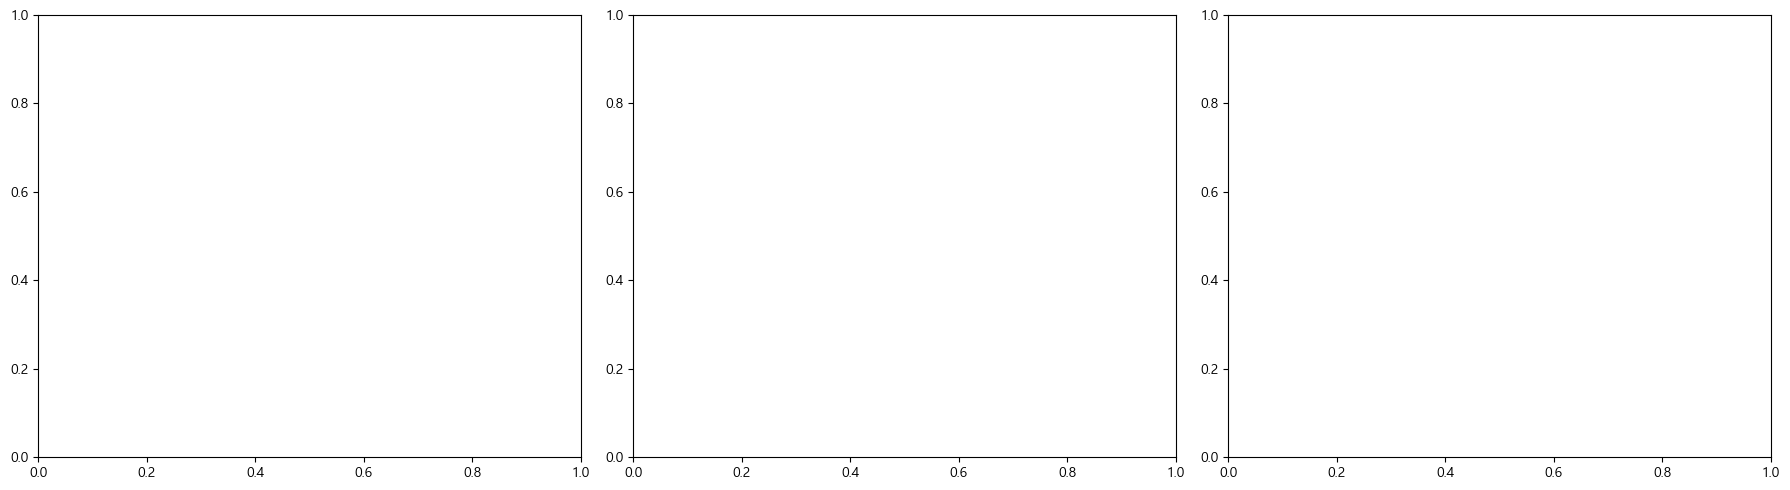

In [7]:
import importlib.util
import sys
from datetime import datetime
from dateutil.relativedelta import relativedelta
from DATA.KEYS import *

# fetch_inbound_tourism 모듈 로드
# spec = importlib.util.spec_from_file_location("fetch_inbound_tourism", "./korea_tourism_stats.py")
# tourism_module = importlib.util.module_from_spec(spec)
# sys.modules["fkorea_tourism_stats"] = tourism_module
# spec.loader.exec_module(tourism_module)

from  ODP.Public_Data.korea_tourism_stats import *


# API 키 설정
key = KEYS['ODPE']

# 국가 코드 설정
countries = {
    '일본': 130,
    '중국': 112,
    '전체': 0
}

# 데이터 수집 기간 자동 생성 (최근 10년)
def generate_date_list(years=10):
    """최근 N년의 월별 날짜 리스트 생성 (YYYYMM 형식)"""
    end_date = datetime.now()
    start_date = end_date - relativedelta(years=years)

    date_list = []
    current = start_date.replace(day=1)

    while current <= end_date:
        date_list.append(current.strftime('%Y%m'))
        current += relativedelta(months=1)

    return date_list

dt_list = generate_date_list(years=15)
print(f"수집 기간: {dt_list[0]} ~ {dt_list[-1]} ({len(dt_list)}개월)")

# 각 국가별 데이터 수집
results = {}

for country_name, country_code in countries.items():
    print(f"\n{country_name} 데이터 수집 중...")

    df = fetch_tourism_data_bulk(
        api_key=key,
        country_code=country_code,
        ed_code='E',
        date_list=dt_list,
        max_workers=5
    )

    # 날짜순 정렬
    if not df.empty:
        df = df.sort_index()

    results[country_name] = df
    print(f"{country_name}: {len(df)}개 데이터 수집 완료")
    print(df.head())

# 결과 확인
print("\n=== 수집 결과 요약 ===")
for country_name, df in results.items():
    print(f"{country_name}: {len(df)}개 행")
    if not df.empty:
        print(f"  기간: {df.index.min()} ~ {df.index.max()}")

# 개별 DataFrame 접근
df_japan = results['일본']
df_china = results['중국']
df_total = results['전체']

# 시각화 예시
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (country_name, df) in enumerate(results.items()):
    if not df.empty and '입국자수' in df.columns:
        df['입국자수'].plot(ax=axes[idx], marker='o', linewidth=2)
        axes[idx].set_title(f'{country_name} 입국자 추이', fontsize=14, fontweight='bold')
        axes[idx].set_ylabel('입국자수', fontsize=12)
        axes[idx].set_xlabel('날짜', fontsize=12)
        axes[idx].grid(True, alpha=0.3)
        axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# CSV 저장 (옵션)
for country_name, df in results.items():
    if not df.empty:
        filename = f'inbound_tourism_{country_name}_{dt_list[0]}_{dt_list[-1]}.csv'
        df.to_csv(filename, encoding='utf-8-sig')
        print(f"{filename} 저장 완료")

=== 1. 과거 실제 데이터 조회 ===
[성공] 1개 HS Code, indicator=expDlr: 228개 행, 기간: 2007-01 ~ 2025-12
hs_code         330790
date                  
2025-03-31  62745900.0
2025-04-30  81058100.0
2025-05-31  75511000.0
2025-06-30  72294700.0
2025-07-31  77836500.0
2025-08-31  70653900.0
2025-09-30  92362000.0
2025-10-31  71059800.0
2025-11-30  75103900.0
2025-12-31  76430500.0
[성공] 1개 HS Code, indicator=expDlr: 84개 행, 기간: 2019-01 ~ 2025-12

최근 5년: 84개 데이터

=== 2. 예측 데이터 조회 ===
[정보] 가장 최근 forecast_date 사용: 2026-01-14
[성공] hs_code=1703, forecast_date=2026-01-14: 24개 행, 7개 indicator
indicator   sarima_expDlr   avg5_expDlr  prophet_expDlr  ensemble_expDlr  \
date                                                                       
2026-01-31   10045.490501   9002.906581     7814.345954      9193.234710   
2026-02-28    8595.524071   8885.544012     8175.075011      8998.550136   
2026-03-31   10702.685664   9144.617405     8110.794585      9331.359860   
2026-04-30    8575.152907   8184.038963     6324

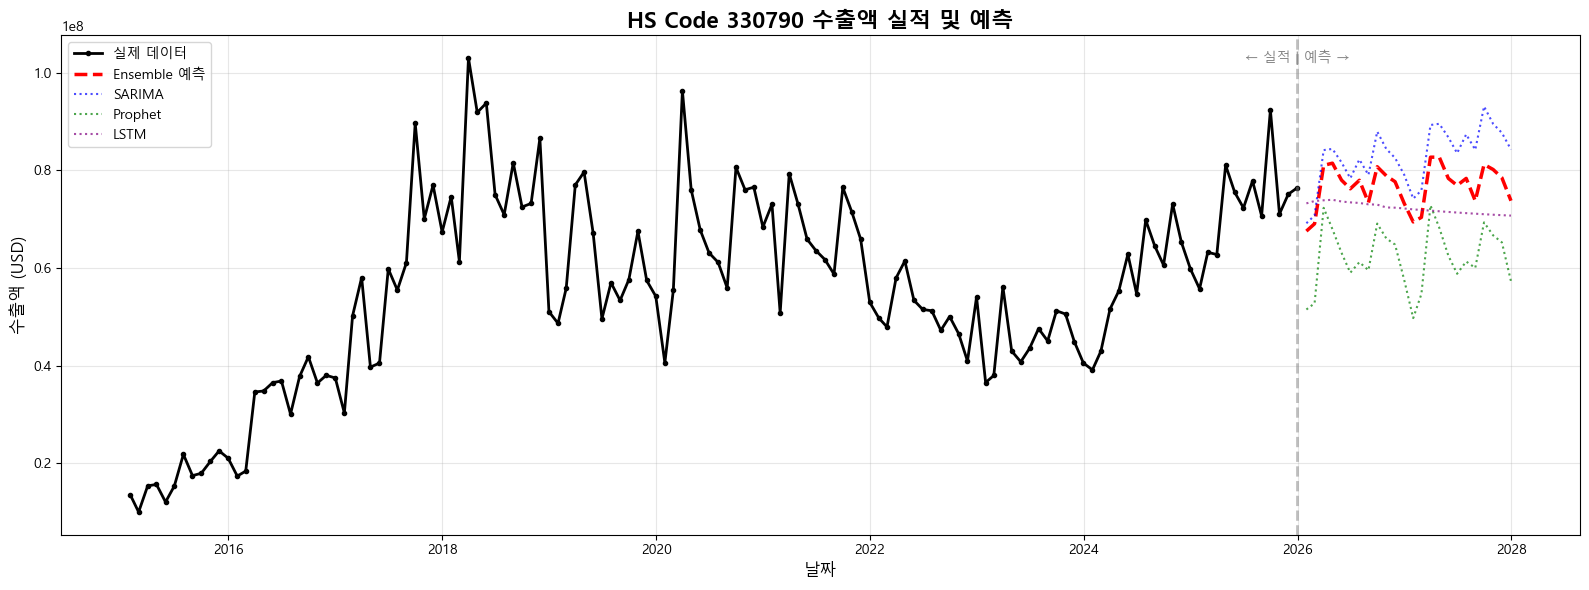


=== 5. 여러 HS Code 비교 ===
[성공] 3개 HS Code, indicator=expDlr: 72개 행, 기간: 2020-01 ~ 2025-12


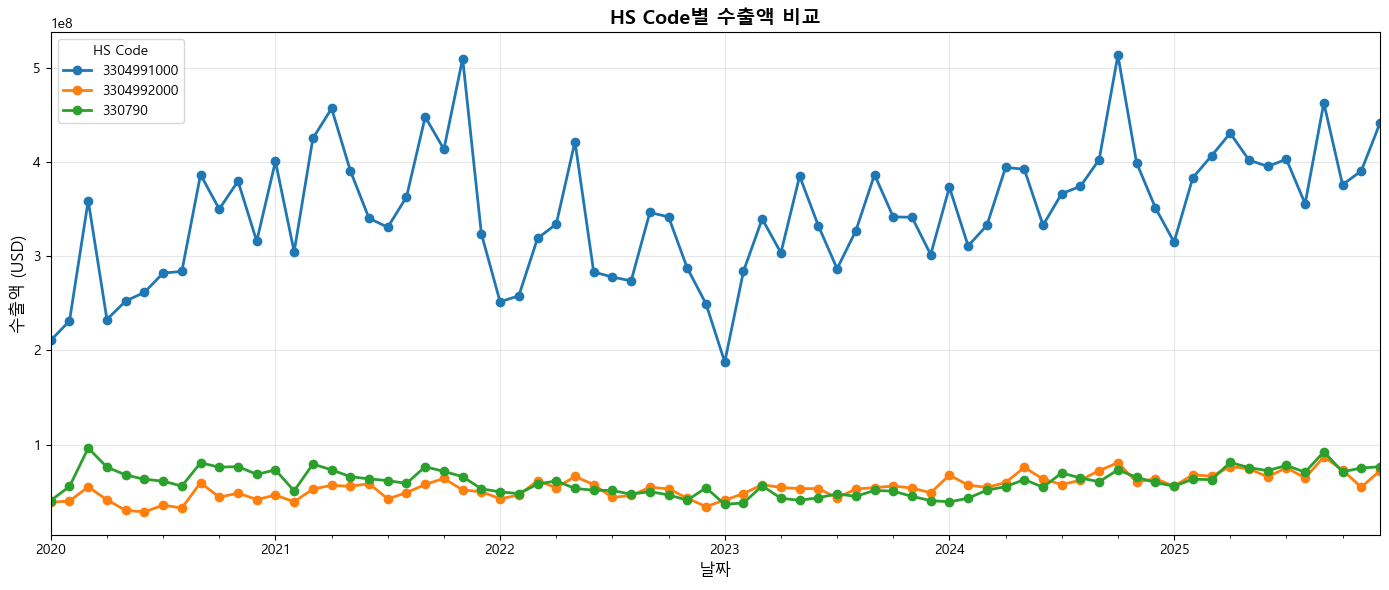


=== 6. 모든 지표 조회 ===
[성공] hs_code=330790: 72개 행, 5개 지표
지표: ['balPayments', 'expDlr', 'expDlr_yoy', 'impDlr', 'impDlr_yoy']
indicator   balPayments      expDlr  expDlr_yoy     impDlr  impDlr_yoy
date                                                                  
2020-01-31   36744000.0  40568100.0   -0.166188  3824060.0   -0.287287
2020-02-29   52602000.0  55470900.0   -0.006949  2868850.0   -0.127779
2020-03-31   92937900.0  96284400.0    0.250293  3346470.0   -0.388096
2020-04-30   72853900.0  76025200.0   -0.045592  3171280.0   -0.685442
2020-05-31   62302300.0  67763900.0    0.009300  5461630.0   -0.111599

사용 가능한 지표: ['balPayments', 'expDlr', 'expDlr_yoy', 'impDlr', 'impDlr_yoy']


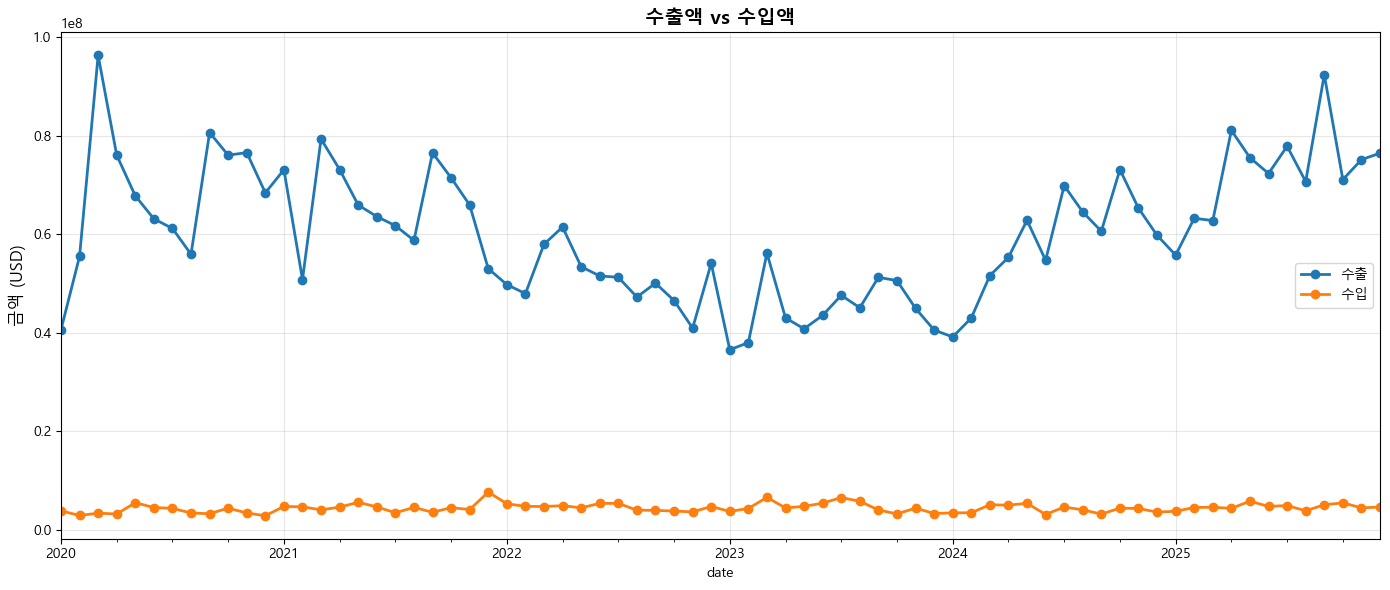


=== 7. 데이터 요약 통계 ===

과거 데이터 통계:
hs_code        330790
count    1.320000e+02
mean     5.527066e+07
std      1.994367e+07
min      9.989800e+06
25%      4.157790e+07
50%      5.587865e+07
75%      7.071438e+07
max      1.030090e+08

예측 데이터 통계 (Ensemble):
count    2.400000e+01
mean     7.672437e+07
std      4.447241e+06
min      6.754890e+07
25%      7.366144e+07
50%      7.797832e+07
75%      8.031476e+07
max      8.270003e+07
Name: ensemble_expDlr, dtype: float64

예측 기간 변화율: 9.21%

=== 8. 사용 가능한 HS Code ===
[정보] 총 1096개의 HS Code 사용 가능
총 1096개 HS Code
처음 10개: ['1201', '121120', '1212', '121221', '151550', '1515500000', '151590', '1515901000', '1518', '1604']


In [52]:
# ====================================
# Jupyter Notebook 사용 예시
# ====================================

import pandas as pd
import matplotlib.pyplot as plt
import sys
import os

# 프로젝트 경로 추가 (필요시)
# sys.path.insert(0, '/path/to/your/project')

from ODP.DB_lookup.get_trade_forecast import (
    get_trade_data_by_hscode,
    get_trade_forecast_by_hscode,
    get_combined_data_and_forecast,
    get_available_hscodes,
    get_available_forecast_dates
)

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows
plt.rcParams['axes.unicode_minus'] = False

# ====================================
# 1. 단일 HS Code 과거 데이터 조회
# ====================================
print("=== 1. 과거 실제 데이터 조회 ===")
hs_code = '330790'

# 전체 기간
df_historical = get_trade_data_by_hscode(hs_code, indicator='expDlr')
print(df_historical.tail(10))

# 최근 5년만
df_recent = get_trade_data_by_hscode(
    hs_code,
    indicator='expDlr',
    start_date='2019-01-01'
)
print(f"\n최근 5년: {len(df_recent)}개 데이터")

# ====================================
# 2. 예측 데이터 조회
# ====================================
print("\n=== 2. 예측 데이터 조회 ===")

# 최신 예측 데이터
df_forecast = get_trade_forecast_by_hscode('1703')
print(df_forecast.head())

# 특정 예측 날짜
df_forecast_specific = get_trade_forecast_by_hscode(
    hs_code= hs_code,
    forecast_date='2026-01-14'
)

# 사용 가능한 예측 날짜 확인
forecast_dates = get_available_forecast_dates('1703')
print(f"\n사용 가능한 예측 날짜: {forecast_dates}")

# ====================================
# 3. 과거 + 예측 데이터 통합 조회
# ====================================
print("\n=== 3. 과거 + 예측 통합 조회 ===")

hs_code = hs_code
historical, forecast = get_combined_data_and_forecast(
    hs_code=hs_code,
    indicator='expDlr',
    start_date='2015-01-01'
)

print(f"과거: {len(historical)}개 행")
print(f"예측: {len(forecast)}개 행")

# ====================================
# 4. 시각화: 과거 + 예측 비교
# ====================================
print("\n=== 4. 과거 + 예측 시각화 ===")

fig, ax = plt.subplots(figsize=(16, 6))

# 과거 데이터 (실제값)
if not historical.empty:
    ax.plot(historical.index, historical[hs_code],
            label='실제 데이터', linewidth=2, color='black', marker='o', markersize=3)

# 예측 데이터 (여러 모델)
if not forecast.empty:
    # Ensemble (주요 예측)
    if 'ensemble_expDlr' in forecast.columns:
        ax.plot(forecast.index, forecast['ensemble_expDlr'],
                label='Ensemble 예측', linewidth=2.5, color='red', linestyle='--')

    # SARIMA
    if 'sarima_expDlr' in forecast.columns:
        ax.plot(forecast.index, forecast['sarima_expDlr'],
                label='SARIMA', linewidth=1.5, color='blue', linestyle=':', alpha=0.7)

    # Prophet
    if 'prophet_expDlr' in forecast.columns:
        ax.plot(forecast.index, forecast['prophet_expDlr'],
                label='Prophet', linewidth=1.5, color='green', linestyle=':', alpha=0.7)

    # LSTM
    if 'lstm_expDlr' in forecast.columns:
        ax.plot(forecast.index, forecast['lstm_expDlr'],
                label='LSTM', linewidth=1.5, color='purple', linestyle=':', alpha=0.7)

ax.set_title(f'HS Code {hs_code} 수출액 실적 및 예측', fontsize=16, fontweight='bold')
ax.set_xlabel('날짜', fontsize=12)
ax.set_ylabel('수출액 (USD)', fontsize=12)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

# 과거와 예측 구분선
if not historical.empty and not forecast.empty:
    last_date = historical.index[-1]
    ax.axvline(x=last_date, color='gray', linestyle='--', linewidth=2, alpha=0.5)
    ax.text(last_date, ax.get_ylim()[1]*0.95, '← 실적 | 예측 →',
            ha='center', fontsize=10, color='gray')

plt.tight_layout()
plt.show()

# ====================================
# 5. 여러 HS Code 비교
# ====================================
print("\n=== 5. 여러 HS Code 비교 ===")

hs_codes = ['3304991000', '3304992000',  '330790']
df_multi = get_trade_data_by_hscode(
    hs_codes,
    indicator='expDlr',
    start_date='2020-01-01'
)

if not df_multi.empty:
    fig, ax = plt.subplots(figsize=(14, 6))
    df_multi.plot(ax=ax, marker='o', linewidth=2)
    ax.set_title('HS Code별 수출액 비교', fontsize=14, fontweight='bold')
    ax.set_ylabel('수출액 (USD)', fontsize=12)
    ax.set_xlabel('날짜', fontsize=12)
    ax.legend(title='HS Code', loc='best')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# ====================================
# 6. 모든 지표 조회 (expDlr, impDlr 등)
# ====================================
print("\n=== 6. 모든 지표 조회 ===")

from ODP.DB_lookup.get_trade_forecast import get_all_indicators_by_hscode

df_all_indicators = get_all_indicators_by_hscode(
    hs_code,
    start_date='2020-01-01'
)

if not df_all_indicators.empty:
    print(df_all_indicators.head())
    print(f"\n사용 가능한 지표: {df_all_indicators.columns.tolist()}")

    # 수출/수입 비교
    fig, ax = plt.subplots(figsize=(14, 6))
    if 'expDlr' in df_all_indicators.columns and 'impDlr' in df_all_indicators.columns:
        df_all_indicators[['expDlr', 'impDlr']].plot(ax=ax, marker='o', linewidth=2)
        ax.set_title('수출액 vs 수입액', fontsize=14, fontweight='bold')
        ax.set_ylabel('금액 (USD)', fontsize=12)
        ax.legend(['수출', '수입'])
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

# ====================================
# 7. 데이터 요약 통계
# ====================================
print("\n=== 7. 데이터 요약 통계 ===")

if not historical.empty:
    print("\n과거 데이터 통계:")
    print(historical.describe())

if not forecast.empty and 'ensemble_expDlr' in forecast.columns:
    print("\n예측 데이터 통계 (Ensemble):")
    print(forecast['ensemble_expDlr'].describe())

    # 예측 변화율
    forecast_change = (
        (forecast['ensemble_expDlr'].iloc[-1] - forecast['ensemble_expDlr'].iloc[0])
        / forecast['ensemble_expDlr'].iloc[0] * 100
    )
    print(f"\n예측 기간 변화율: {forecast_change:.2f}%")

# ====================================
# 8. 사용 가능한 HS Code 목록 확인
# ====================================
print("\n=== 8. 사용 가능한 HS Code ===")

available_codes = get_available_hscodes()
print(f"총 {len(available_codes)}개 HS Code")
print(f"처음 10개: {available_codes[:10]}")


#### 두 데이터 프레림을 결함하여 시각화 및 자료저장

In [53]:
def combine_and_visualize_export_forecast(
    df_historical: pd.DataFrame,
    df_forecast: pd.DataFrame,
    forecast_model: str = 'ensemble_expDlr',
    save_dir: str = None
) -> pd.DataFrame:
    """
    과거 데이터와 예측 데이터를 결합하고 시각화

    Args:
        df_historical: 과거 데이터
        df_forecast: 예측 데이터
        forecast_model: 시각화할 예측 모델 (기본값: 'ensemble_expDlr')
        save_dir: 그림 저장 디렉토리 (파일명은 자동 생성)

    Returns:
        pd.DataFrame: 결합된 데이터프레임
    """

    print(f"\n{'='*60}")
    print("데이터 결합 및 분석 시작")
    print(f"{'='*60}\n")

    # ================================
    # 1. 과거 데이터 처리
    # ================================

    df_hist = df_historical.copy()

    if not isinstance(df_hist.index, pd.DatetimeIndex):
        df_hist.index = pd.to_datetime(df_hist.index)
    df_hist.index.name = 'date'

    if len(df_hist.columns) > 0:
        df_hist = df_hist.iloc[:, [0]]
        df_hist.columns = ['value']
        # df_hist['value'] = df_hist['value'] / 1000

    print(f"[과거 데이터]")
    print(f"  기간: {df_hist.index.min().strftime('%Y-%m')} ~ {df_hist.index.max().strftime('%Y-%m')}")
    print(f"  데이터 수: {len(df_hist)}개")
    print(f"  평균: ${df_hist['value'].mean():,.0f}K")

    # ================================
    # 2. 예측 데이터 처리
    # ================================

    df_fc = df_forecast.copy()

    if not isinstance(df_fc.index, pd.DatetimeIndex):
        df_fc.index = pd.to_datetime(df_fc.index)
    df_fc.index.name = 'date'

    if forecast_model not in df_fc.columns:
        print(f"\n[경고] '{forecast_model}' 모델을 찾을 수 없습니다.")
        print(f"사용 가능한 모델: {df_fc.columns.tolist()}")
        forecast_model = df_fc.columns[0]
        print(f"'{forecast_model}' 모델을 사용합니다.\n")

    df_fc = df_fc[[forecast_model]]
    df_fc.columns = ['value']

    print(f"\n[예측 데이터]")
    print(f"  모델: {forecast_model}")
    print(f"  기간: {df_fc.index.min().strftime('%Y-%m')} ~ {df_fc.index.max().strftime('%Y-%m')}")
    print(f"  데이터 수: {len(df_fc)}개")

    # ================================
    # 3. 데이터 결합
    # ================================

    df_hist['type'] = 'historical'
    df_fc['type'] = 'forecast'

    df_combined = pd.concat([df_hist, df_fc], axis=0)
    df_combined = df_combined.sort_index()
    df_combined = df_combined[~df_combined.index.duplicated(keep='first')]

    # ================================
    # 4. YoY 증가율 계산
    # ================================

    df_combined['yoy'] = df_combined['value'].pct_change(periods=12) * 100

    # ================================
    # 5. 연간 YoY Growth 평균 계산
    # ================================

    # 연도별로 그룹화하여 YoY 평균 계산
    df_combined['year'] = df_combined.index.year

    annual_yoy = df_combined.groupby(['year', 'type'])['yoy'].mean().reset_index()

    print(f"\n{'='*60}")
    print(f"연간 YoY Growth 평균 ({forecast_model})")
    print(f"{'='*60}")

    # 과거 데이터의 연간 YoY
    hist_annual = annual_yoy[annual_yoy['type'] == 'historical']
    if not hist_annual.empty:
        print(f"\n[과거 실적 - 연간 평균 YoY]")
        for _, row in hist_annual.iterrows():
            if not pd.isna(row['yoy']):
                print(f"  {int(row['year'])}: {row['yoy']:+.2f}%")

        overall_hist_yoy = hist_annual['yoy'].mean()
        print(f"\n  전체 과거 평균: {overall_hist_yoy:+.2f}%")

    # 예측 데이터의 연간 YoY
    fc_annual = annual_yoy[annual_yoy['type'] == 'forecast']
    if not fc_annual.empty:
        print(f"\n[예측 - 연간 평균 YoY]")
        for _, row in fc_annual.iterrows():
            if not pd.isna(row['yoy']):
                print(f"  {int(row['year'])}: {row['yoy']:+.2f}%")

        overall_fc_yoy = fc_annual['yoy'].mean()
        print(f"\n  전체 예측 평균: {overall_fc_yoy:+.2f}%")

    print(f"{'='*60}\n")

    # ================================
    # 6. 시각화
    # ================================

    split_idx = df_hist.index.max()

    hist_data = df_combined[df_combined['type'] == 'historical'].copy()
    fc_data = df_combined[df_combined['type'] == 'forecast'].copy()

    if not fc_data.empty and not hist_data.empty:
        last_hist = hist_data.iloc[[-1]].copy()
        last_hist['type'] = 'forecast'
        fc_data = pd.concat([last_hist, fc_data])
        fc_data = fc_data[~fc_data.index.duplicated(keep='first')]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

    # 모델명을 한글로 변환
    model_name_kr = {
        'ensemble_expDlr': 'Ensemble',
        'sarima_expDlr': 'SARIMA',
        'avg5_expDlr': 'Moving Average',
        'prophet_expDlr': 'Prophet',
        'lstm_expDlr': 'LSTM',
        'theta_expDlr': 'Theta',
        'ets_expDlr': 'ETS'
    }.get(forecast_model, forecast_model.replace('_expDlr', '').title())

    fig.suptitle(f'HS Code {hs_code} 화장품 수출 분석 및 예측 ({model_name_kr} 모델)',
                 fontsize=18, fontweight='bold', y=0.995)

    # 상단: 수출액
    ax1.plot(hist_data.index, hist_data['value'],
             color='#2E3440', linewidth=2.5,
             label='실제 수출액', marker='o', markersize=3, markevery=3, zorder=10)

    ax1.plot(fc_data.index, fc_data['value'],
             color='#BF616A', linewidth=2.5, linestyle='--',
             label=f'예측 ({model_name_kr})', marker='s', markersize=3, markevery=2, zorder=9)

    ax1.axvline(x=split_idx, color='gray', linestyle=':', linewidth=2, alpha=0.7)
    ax1.text(split_idx, ax1.get_ylim()[1]*0.95, '← 실적 | 예측 →',
            ha='center', fontsize=11, color='gray', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8))

    ax1.axvspan(df_combined.index.min(), split_idx, alpha=0.03, color='blue')
    ax1.axvspan(split_idx, df_combined.index.max(), alpha=0.03, color='red')

    ax1.set_title('수출액 추이 및 예측', fontsize=14, fontweight='bold', pad=15)
    ax1.set_ylabel('수출액 (천 USD)', fontsize=12, fontweight='bold')
    ax1.legend(loc='upper left', fontsize=11, framealpha=0.95, shadow=True)
    ax1.grid(True, alpha=0.3, linestyle='--')
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}K'))

    # 하단: YoY
    hist_yoy = hist_data['yoy'].dropna()
    ax2.plot(hist_yoy.index, hist_yoy.values,
            color='#2E3440', linewidth=2.5, label='실제 YoY',
            marker='o', markersize=3, markevery=3, zorder=10)

    fc_yoy = fc_data['yoy'].dropna()
    ax2.plot(fc_yoy.index, fc_yoy.values,
            color='#BF616A', linewidth=2.5, linestyle='--',
            label=f'예측 YoY ({model_name_kr})', marker='s', markersize=3, markevery=2, zorder=9)

    ax2.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.3)
    ax2.axvline(x=split_idx, color='gray', linestyle=':', linewidth=2, alpha=0.7)
    ax2.axvspan(df_combined.index.min(), split_idx, alpha=0.03, color='blue')
    ax2.axvspan(split_idx, df_combined.index.max(), alpha=0.03, color='red')

    ax2.set_title('YoY 증가율 추이 및 예측', fontsize=14, fontweight='bold', pad=15)
    ax2.set_xlabel('날짜', fontsize=12, fontweight='bold')
    ax2.set_ylabel('YoY 증가율 (%)', fontsize=12, fontweight='bold')
    ax2.legend(loc='upper left', fontsize=11, framealpha=0.95, shadow=True)
    ax2.grid(True, alpha=0.3, linestyle='--')
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.1f}%'))

    plt.tight_layout()

    # ================================
    # 7. 파일명 생성 및 저장
    # ================================

    if save_dir:
        # 디렉토리 생성
        if not os.path.exists(save_dir):
            os.makedirs(save_dir)
            print(f"[디렉토리 생성] {save_dir}")

        # 현재 날짜 및 시간
        timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

        # 모델명 (영문, 언더스코어 제거)
        model_short = forecast_model.replace('_expDlr', '').replace('_', '')

        # 파일명 생성
        filename = f'cosmetic_export_{model_short}_{timestamp}.png'
        save_path = os.path.join(save_dir, filename)

        # 이미지 저장
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"\n[PNG 저장] {save_path}")

        # CSV 저장
        csv_filename = f'cosmetic_export_{model_short}_{timestamp}.csv'
        csv_path = os.path.join(save_dir, csv_filename)

        # 연간 YoY 정보도 CSV에 추가
        df_output = df_combined.copy()
        df_output['annual_yoy'] = df_output.groupby('year')['yoy'].transform('mean')

        df_output.to_csv(csv_path, encoding='utf-8-sig')
        print(f"[CSV 저장] {csv_path}")

    plt.show()

    # year 컬럼 제거 (원본 유지)
    df_combined = df_combined.drop('year', axis=1)

    return df_combined


def compare_annual_yoy_growth(
    df1: pd.DataFrame,
    df2: pd.DataFrame,
    df3: pd.DataFrame,
    model1: str = 'ensemble',
    model2: str = 'sarima',
    model3: str = 'lstm'
) -> pd.DataFrame:
    """
    여러 모델의 연간 YoY Growth를 비교

    Args:
        df1, df2, df3: combine_and_visualize_export_forecast 함수의 결과
        model1, model2, model3: 각 데이터프레임의 모델명

    Returns:
        pd.DataFrame: 모델별 연간 YoY 비교표
    """

    print(f"\n{'='*60}")
    print("모델별 연간 YoY Growth 비교")
    print(f"{'='*60}\n")

    results = []

    for df, model_name in [(df1, model1), (df2, model2), (df3, model3)]:
        df_temp = df.copy()
        df_temp['year'] = df_temp.index.year

        # 전체 평균
        overall_yoy = df_temp['yoy'].mean()

        # 과거 평균
        hist_yoy = df_temp[df_temp['type'] == 'historical']['yoy'].mean()

        # 예측 평균
        fc_yoy = df_temp[df_temp['type'] == 'forecast']['yoy'].mean()

        # 연도별 평균
        annual = df_temp.groupby(['year', 'type'])['yoy'].mean().unstack(fill_value=np.nan)

        results.append({
            'model': model_name,
            'overall_yoy': overall_yoy,
            'historical_yoy': hist_yoy,
            'forecast_yoy': fc_yoy,
            'annual_data': annual
        })

        print(f"[{model_name.upper()} 모델]")
        print(f"  전체 평균 YoY: {overall_yoy:+.2f}%")
        print(f"  과거 평균 YoY: {hist_yoy:+.2f}%")
        print(f"  예측 평균 YoY: {fc_yoy:+.2f}%")
        print()

    # 비교 테이블 생성
    comparison_df = pd.DataFrame([
        {
            '모델': r['model'],
            '전체 평균 YoY (%)': f"{r['overall_yoy']:+.2f}",
            '과거 평균 YoY (%)': f"{r['historical_yoy']:+.2f}",
            '예측 평균 YoY (%)': f"{r['forecast_yoy']:+.2f}"
        }
        for r in results
    ])

    print("="*60)
    print("종합 비교표")
    print("="*60)
    print(comparison_df.to_string(index=False))
    print("="*60)

    return comparison_df


데이터 결합 및 분석 시작

[과거 데이터]
  기간: 2015-01 ~ 2025-12
  데이터 수: 132개
  평균: $55,270,655K

[예측 데이터]
  모델: ensemble_expDlr
  기간: 2026-01 ~ 2027-12
  데이터 수: 24개

연간 YoY Growth 평균 (ensemble_expDlr)

[과거 실적 - 연간 평균 YoY]
  2016: +101.48%
  2017: +78.20%
  2018: +47.46%
  2019: -21.21%
  2020: +12.96%
  2021: +0.54%
  2022: -21.70%
  2023: -11.30%
  2024: +30.51%
  2025: +27.00%

  전체 과거 평균: +24.39%

[예측 - 연간 평균 YoY]
  2026: +5.88%
  2027: +1.21%

  전체 예측 평균: +3.55%


[PNG 저장] C:\Users\82108\OneDrive\바탕 화면\investment\data\analysis_results\KS_Cosmetic\cosmetic_export_ensemble_20260203_205744.png
[CSV 저장] C:\Users\82108\OneDrive\바탕 화면\investment\data\analysis_results\KS_Cosmetic\cosmetic_export_ensemble_20260203_205744.csv


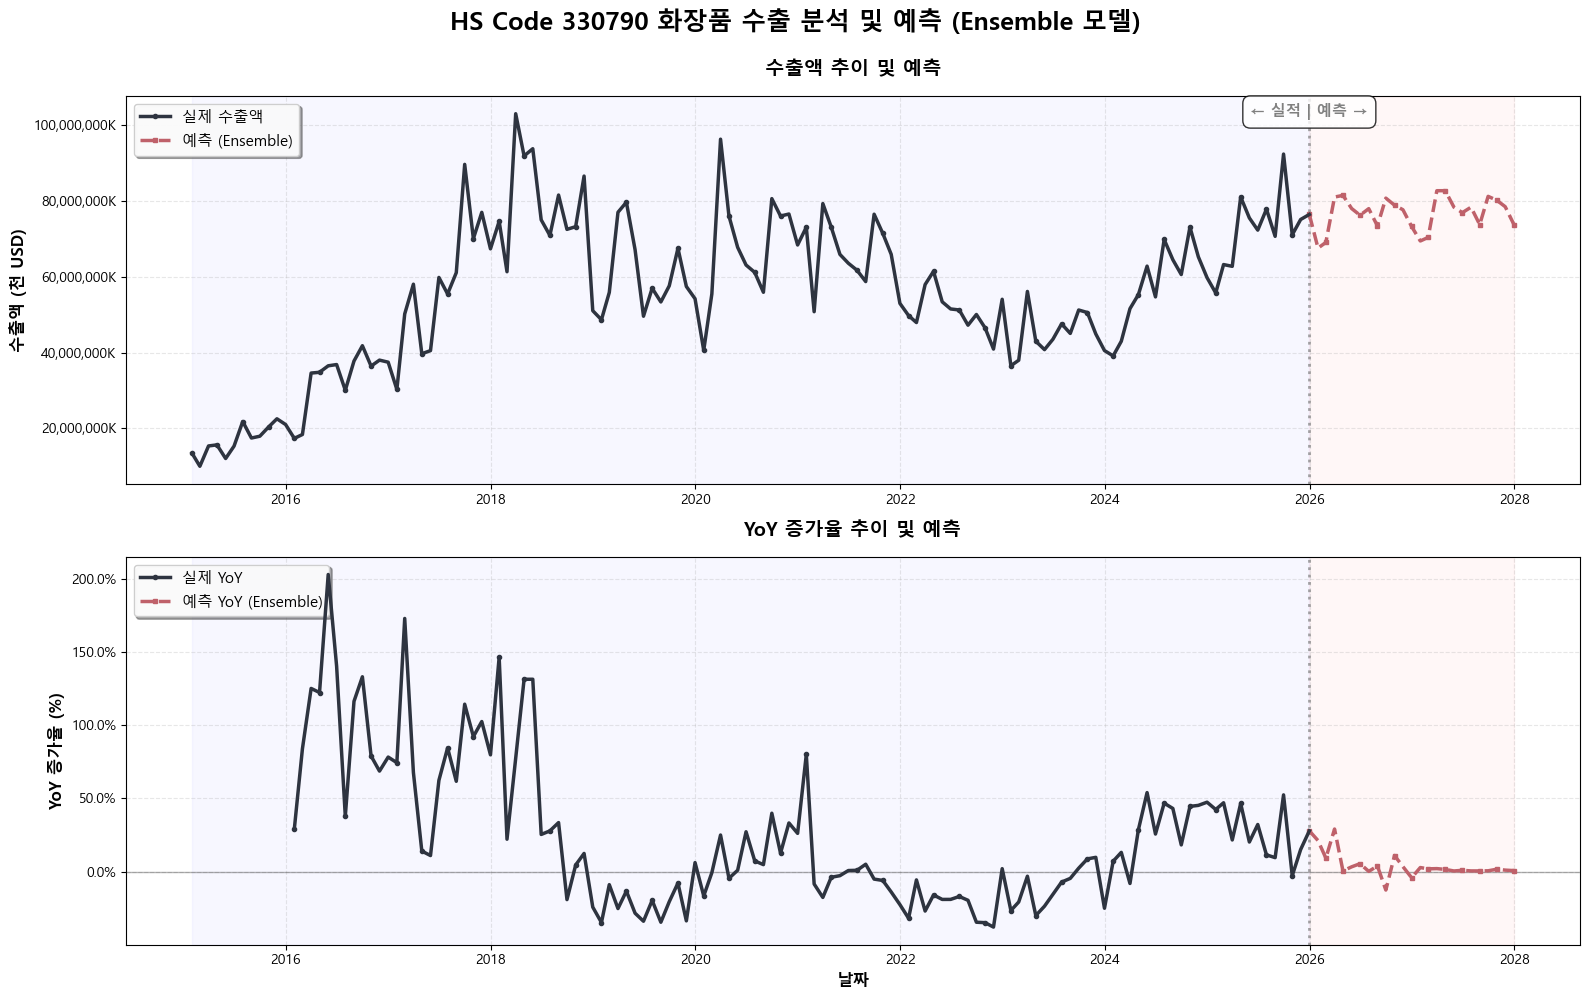


데이터 결합 및 분석 시작

[과거 데이터]
  기간: 2015-01 ~ 2025-12
  데이터 수: 132개
  평균: $55,270,655K

[예측 데이터]
  모델: sarima_expDlr
  기간: 2026-01 ~ 2027-12
  데이터 수: 24개

연간 YoY Growth 평균 (sarima_expDlr)

[과거 실적 - 연간 평균 YoY]
  2016: +101.48%
  2017: +78.20%
  2018: +47.46%
  2019: -21.21%
  2020: +12.96%
  2021: +0.54%
  2022: -21.70%
  2023: -11.30%
  2024: +30.51%
  2025: +27.00%

  전체 과거 평균: +24.39%

[예측 - 연간 평균 YoY]
  2026: +11.31%
  2027: +6.42%

  전체 예측 평균: +8.87%


[PNG 저장] C:\Users\82108\OneDrive\바탕 화면\investment\data\analysis_results\KS_Cosmetic\cosmetic_export_sarima_20260203_205746.png
[CSV 저장] C:\Users\82108\OneDrive\바탕 화면\investment\data\analysis_results\KS_Cosmetic\cosmetic_export_sarima_20260203_205746.csv


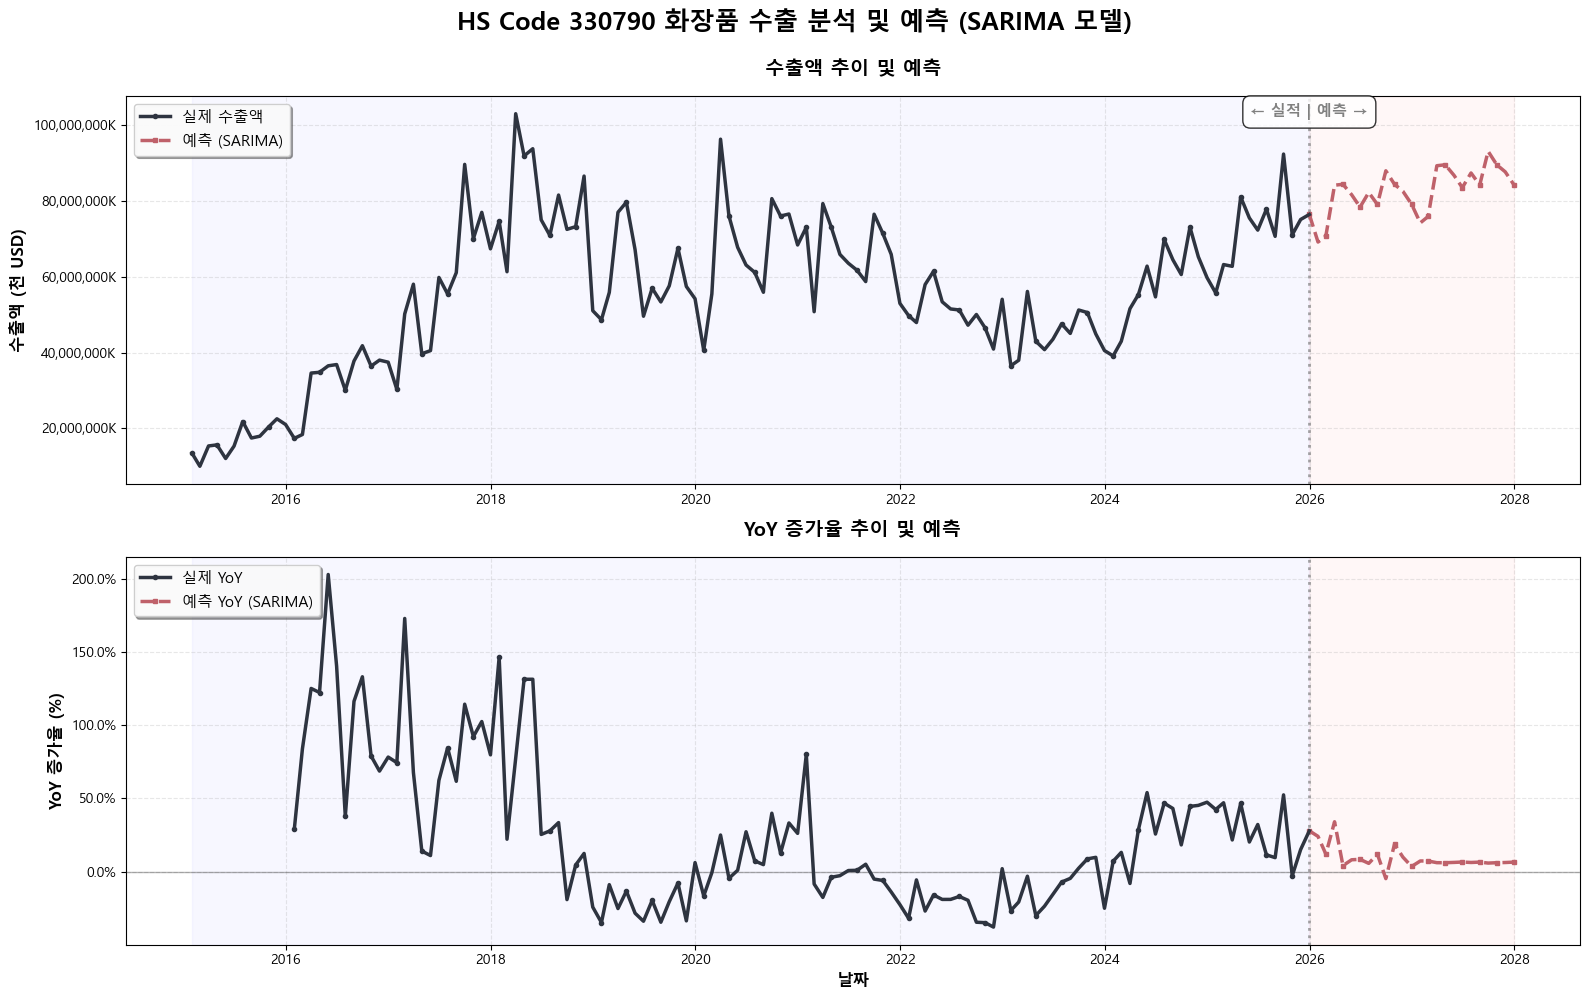


데이터 결합 및 분석 시작

[과거 데이터]
  기간: 2015-01 ~ 2025-12
  데이터 수: 132개
  평균: $55,270,655K

[예측 데이터]
  모델: lstm_expDlr
  기간: 2026-01 ~ 2027-12
  데이터 수: 24개

연간 YoY Growth 평균 (lstm_expDlr)

[과거 실적 - 연간 평균 YoY]
  2016: +101.48%
  2017: +78.20%
  2018: +47.46%
  2019: -21.21%
  2020: +12.96%
  2021: +0.54%
  2022: -21.70%
  2023: -11.30%
  2024: +30.51%
  2025: +27.00%

  전체 과거 평균: +24.39%

[예측 - 연간 평균 YoY]
  2026: +2.11%
  2027: -2.53%

  전체 예측 평균: -0.21%


[PNG 저장] C:\Users\82108\OneDrive\바탕 화면\investment\data\analysis_results\KS_Cosmetic\cosmetic_export_lstm_20260203_205747.png
[CSV 저장] C:\Users\82108\OneDrive\바탕 화면\investment\data\analysis_results\KS_Cosmetic\cosmetic_export_lstm_20260203_205747.csv


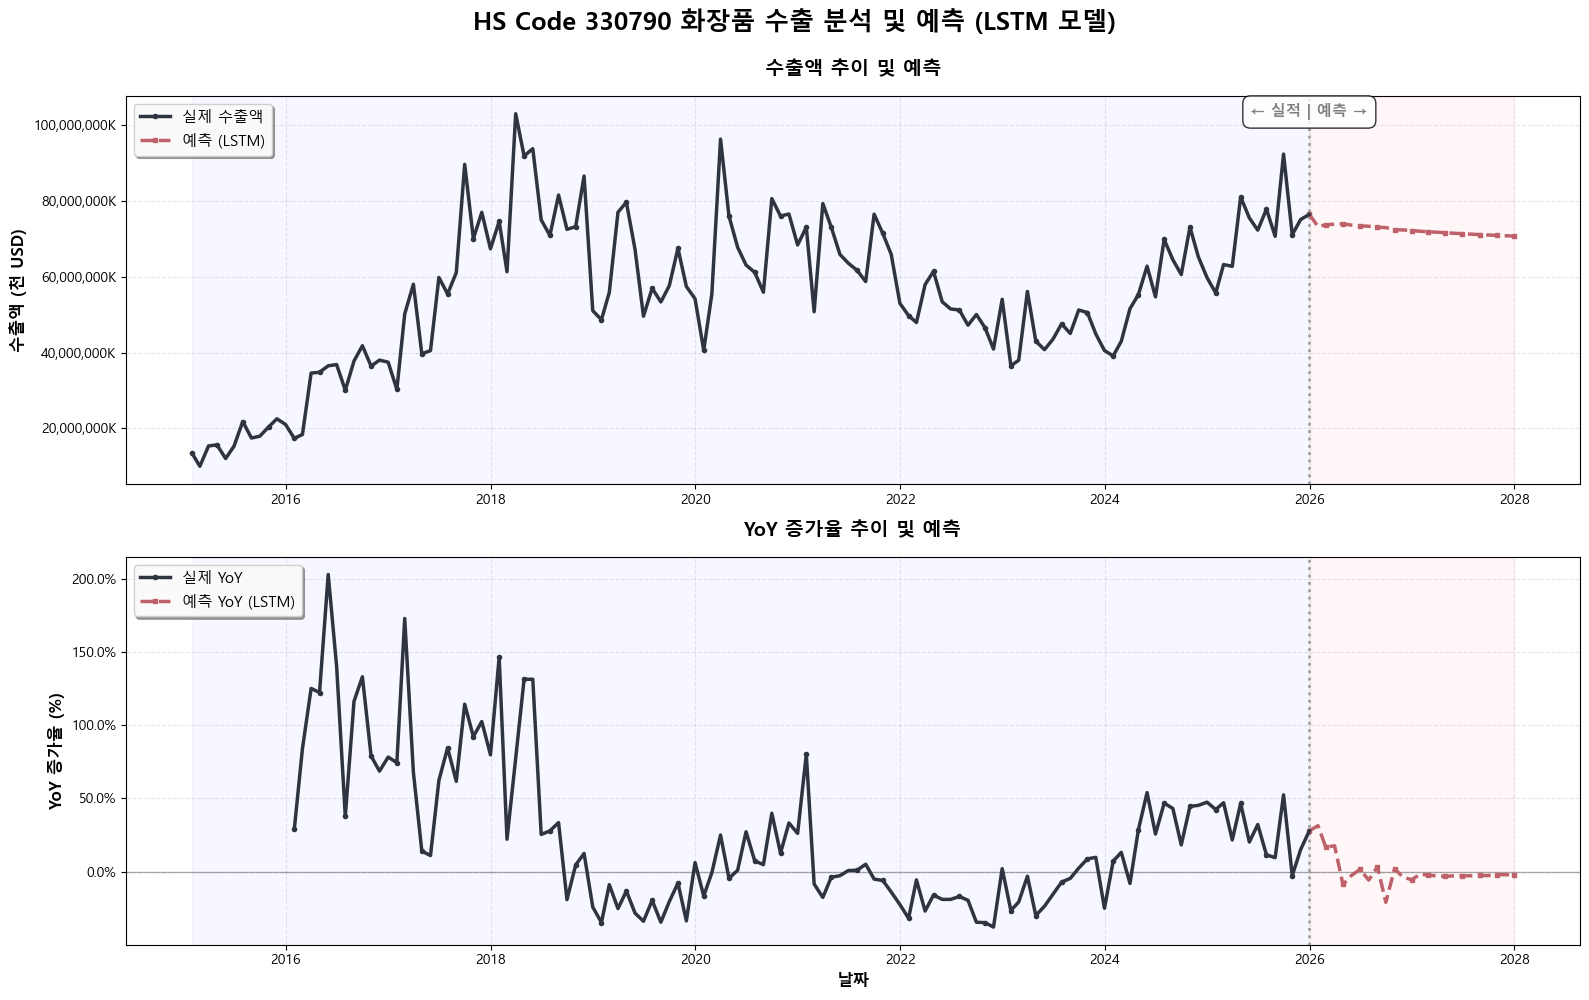


모델별 연간 YoY Growth 비교

[ENSEMBLE 모델]
  전체 평균 YoY: +20.92%
  과거 평균 YoY: +24.39%
  예측 평균 YoY: +3.55%

[SARIMA 모델]
  전체 평균 YoY: +21.81%
  과거 평균 YoY: +24.39%
  예측 평균 YoY: +8.87%

[LSTM 모델]
  전체 평균 YoY: +20.29%
  과거 평균 YoY: +24.39%
  예측 평균 YoY: -0.21%

종합 비교표
      모델 전체 평균 YoY (%) 과거 평균 YoY (%) 예측 평균 YoY (%)
Ensemble        +20.92        +24.39         +3.55
  SARIMA        +21.81        +24.39         +8.87
    LSTM        +20.29        +24.39         -0.21

[비교표 저장] C:\Users\82108\OneDrive\바탕 화면\investment\data\analysis_results\KS_Cosmetic\model_comparison_20260203_205748.csv


In [54]:
# 예시 데이터 생성 (실제로는 여러분의 데이터프레임 사용)
# df_historical = ... (첫 번째 이미지의 데이터)
# df_forecast = ... (두 번째 이미지의 데이터)



# 저장 디렉토리 설정
save_directory = r'C:\Users\82108\OneDrive\바탕 화면\investment\data\analysis_results\KS_Cosmetic'

# 1. Ensemble 모델
df1 = combine_and_visualize_export_forecast(
    df_historical=historical,
    df_forecast=forecast,
    forecast_model='ensemble_expDlr',
    save_dir=save_directory
)

# 2. SARIMA 모델
df2 = combine_and_visualize_export_forecast(
    df_historical=historical,
    df_forecast=forecast,
    forecast_model='sarima_expDlr',
    save_dir=save_directory
)

# 3. LSTM 모델
df3 = combine_and_visualize_export_forecast(
    df_historical=historical,
    df_forecast=forecast,
    forecast_model='lstm_expDlr',
    save_dir=save_directory
)

# 모델 비교
comparison = compare_annual_yoy_growth(
    df1, df2, df3,
    model1='Ensemble',
    model2='SARIMA',
    model3='LSTM'
)

# 비교표 저장
comparison_path = os.path.join(save_directory,
                               f'model_comparison_{datetime.now().strftime("%Y%m%d_%H%M%S")}.csv')
comparison.to_csv(comparison_path, index=False, encoding='utf-8-sig')
print(f"\n[비교표 저장] {comparison_path}")


In [55]:
df2

,value,type,yoy
date,,,
2015-01-31,1.344960e+07,historical,NaN
2015-02-28,9.989800e+06,historical,NaN
2015-03-31,1.535580e+07,historical,NaN
2015-04-30,1.563890e+07,historical,NaN
2015-05-31,1.204090e+07,historical,NaN
...,...,...,...
2027-08-31,8.420470e+07,forecast,6.507897
2027-09-30,9.309065e+07,forecast,5.850344
2027-10-31,8.952279e+07,forecast,6.097722


#### 국가별 화장품 수출 데이터 (미국, 일본, 중국, 홍콩)

=== HS Code 330499 화장품 수출 데이터 수집 ===
[HS Code] 330499 (6자리)

HS: 330499, 국가: ['미국', '홍콩', '일본', '중국']
기간: 74개월

[시작] 총 296개 요청
HS: 330499, 국가: ['US', 'HK', 'JP', 'CN']
기간: 202001~202602

[OK] 202001, US: 5개[OK] 202002, US: 5개

[OK] 202004, US: 5개
[OK] 202003, US: 5개
[OK] 202005, US: 5개
[OK] 202006, US: 5개
[OK] 202008, US: 5개
[OK] 202009, US: 5개
[OK] 202007, US: 5개
[OK] 202010, US: 5개
[진행] 10/296 (성공: 10)
[OK] 202012, US: 5개
[OK] 202011, US: 5개
[OK] 202101, US: 5개[OK] 202102, US: 5개

[OK] 202103, US: 5개
[OK] 202104, US: 5개
[OK] 202105, US: 5개
[OK] 202106, US: 5개
[OK] 202107, US: 5개
[OK] 202108, US: 5개
[진행] 20/296 (성공: 20)
[OK] 202109, US: 5개
[OK] 202110, US: 5개
[OK] 202112, US: 5개[OK] 202111, US: 5개

[OK] 202202, US: 5개
[OK] 202203, US: 5개
[OK] 202204, US: 5개
[OK] 202201, US: 5개
[OK] 202205, US: 5개
[OK] 202207, US: 5개
[진행] 30/296 (성공: 30)
[OK] 202206, US: 5개
[OK] 202209, US: 5개
[OK] 202210, US: 5개
[OK] 202211, US: 5개
[OK] 202208, US: 5개
[OK] 202212, US: 5개
[OK] 202302, US: 5개
[OK] 20230

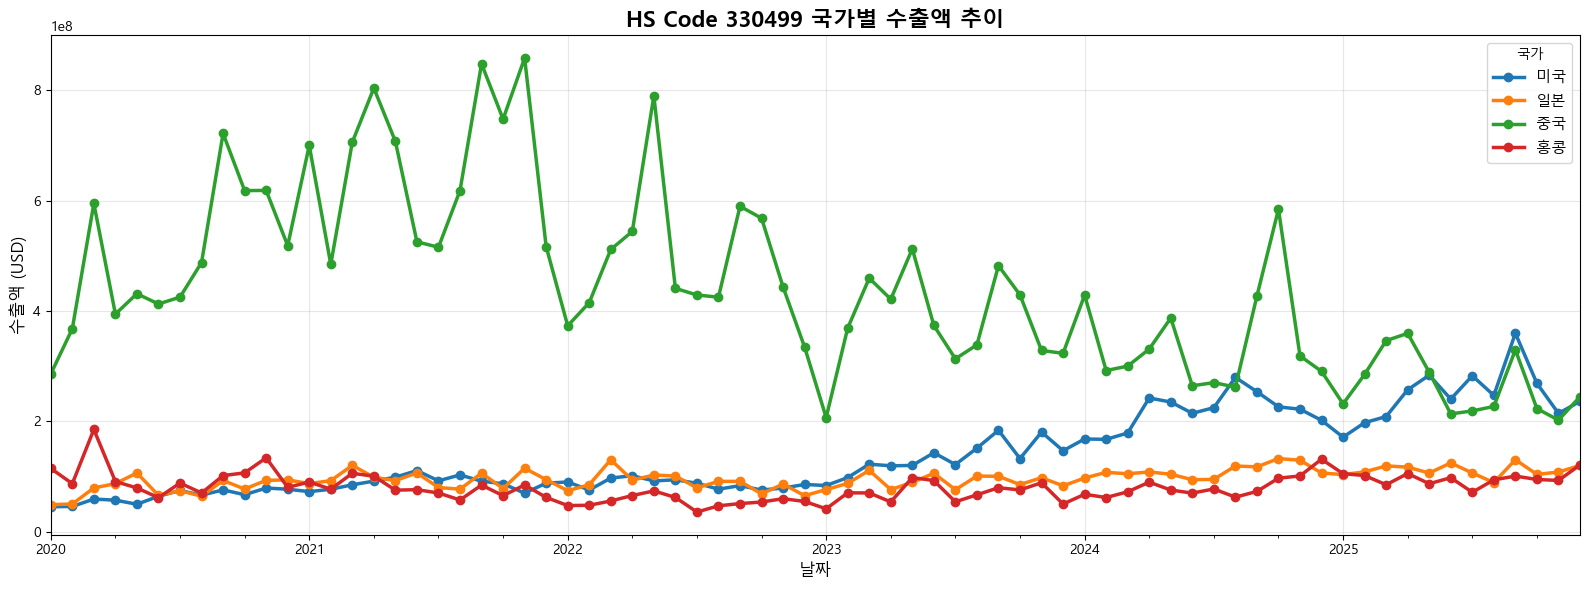

In [57]:
# 1_Cosmetic.ipynb

import sys
import os

# 프로젝트 루트 경로 추가
project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# 모듈 임포트
from ODP.Public_Data.get_export_data_by_country import (
    get_export_data_by_countries,
    generate_date_list,
    COUNTRY_CODES
)

import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# HS Code 330499 데이터 수집
print(f"=== HS Code {hs_code} 화장품 수출 데이터 수집 ===")

df_cosmetic = get_export_data_by_countries(
    hs_code='330499',
    countries=['미국', '홍콩', '일본', '중국'],
    start_date='2020-01',
    return_wide_format=True
)

# 결과 확인
print(df_cosmetic)

# 시각화
if not df_cosmetic.empty:
    fig, ax = plt.subplots(figsize=(16, 6))
    df_cosmetic.plot(ax=ax, marker='o', linewidth=2.5)
    ax.set_title('HS Code 330499 국가별 수출액 추이', fontsize=16, fontweight='bold')
    ax.set_ylabel('수출액 (USD)', fontsize=12)
    ax.set_xlabel('날짜', fontsize=12)
    ax.legend(title='국가', fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [60]:
df_cosmetic.tail(13)

df_cosmetic.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 72 entries, 2020-01-31 to 2025-12-31
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   미국      72 non-null     int64
 1   일본      72 non-null     int64
 2   중국      72 non-null     int64
 3   홍콩      72 non-null     int64
dtypes: int64(4)
memory usage: 2.8 KB


데이터프레임 정보:
country_name        미국         일본         중국         홍콩  \
0             45336486   49070224  286067486  114805440   
1             45834128   50267122  367931066   87153802   
2             59241654   79449450  595107010  185379420   
3             57226278   87225660  394653642   91053930   
4             49857512  106594420  431469106   79393128   

country_name                          date  
0            1970-01-01 00:00:00.000000000  
1            1970-01-01 00:00:00.000000001  
2            1970-01-01 00:00:00.000000002  
3            1970-01-01 00:00:00.000000003  
4            1970-01-01 00:00:00.000000004  

인덱스 정보:
RangeIndex(start=0, stop=72, step=1)

마지막 데이터:
country_name         미국         일본         중국         홍콩  \
67            247161668   89167108  227114612   94062200   
68            359764434  130568208  329711440  100895840   
69            268969780  103962420  223165368   94730284   
70            214562038  108191012  202423086   93014282   
71      

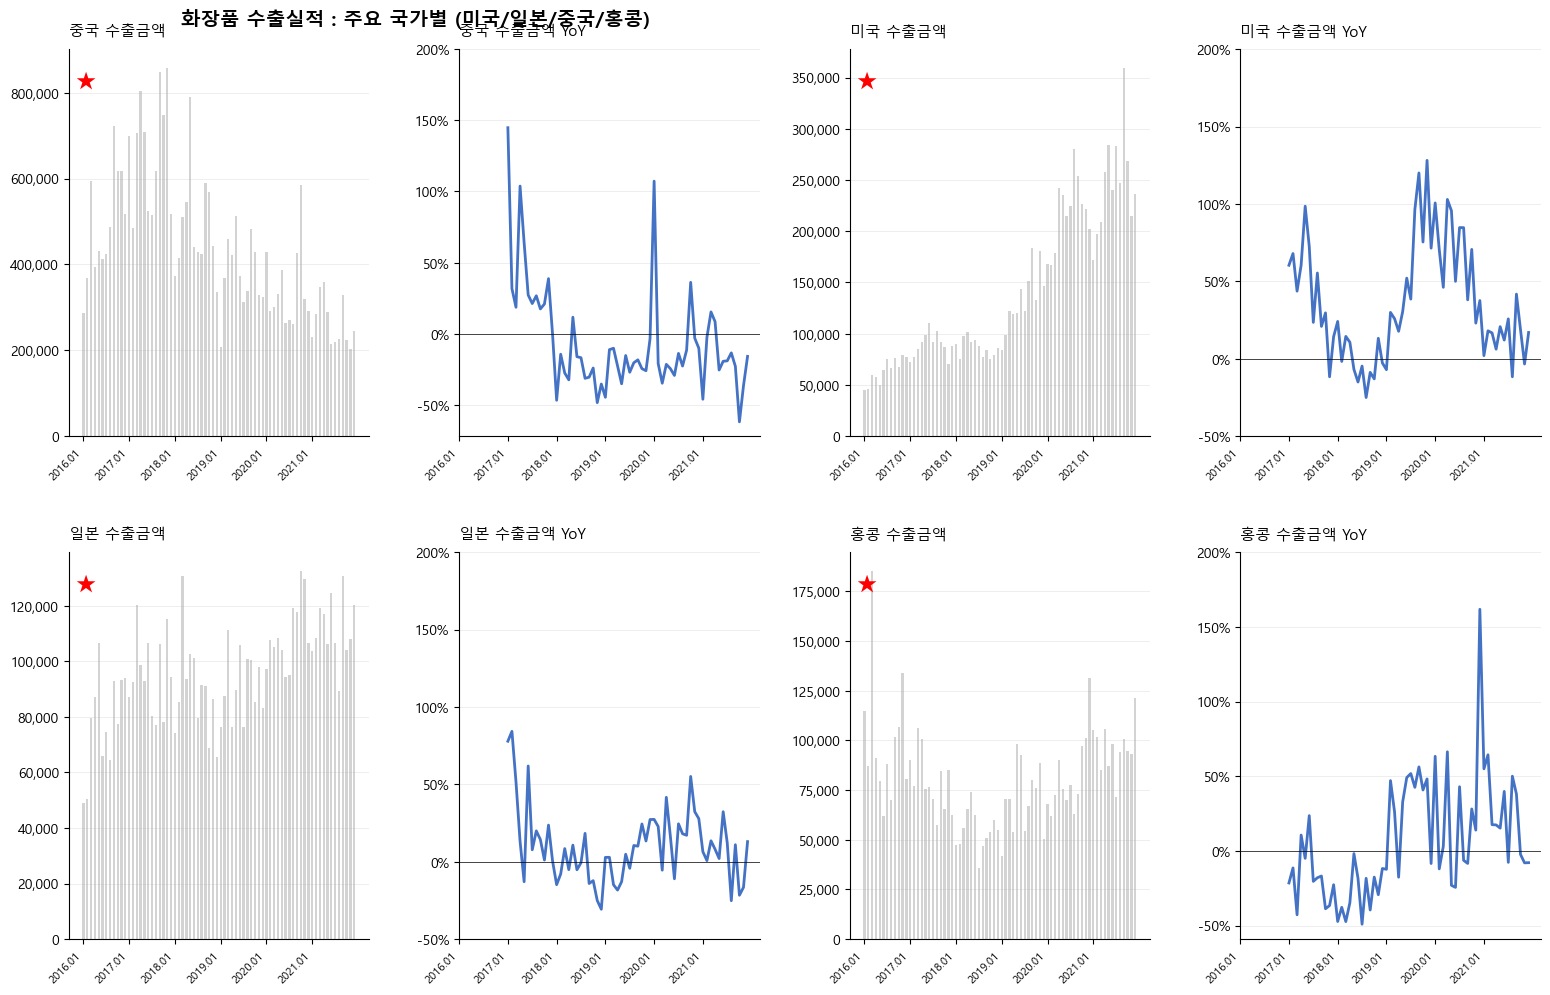

In [70]:
from matplotlib.gridspec import GridSpec

# 데이터프레임 구조 확인
print("데이터프레임 정보:")
print(df_cosmetic.head())
print("\n인덱스 정보:")
print(df_cosmetic.index)
print("\n마지막 데이터:")
print(df_cosmetic.tail())

# 기존 date 컬럼이 있으면 삭제
if 'date' in df_cosmetic.columns:
    df_cosmetic = df_cosmetic.drop('date', axis=1)

# 인덱스를 문자열로 변환 후 datetime으로 변환
# 인덱스가 숫자인 경우, 원본 데이터에서 날짜 정보를 가져와야 합니다
# 첫 번째 이미지에서 본 날짜 범위를 기준으로 날짜 생성
start_date = '2016-01-31'  # 실제 데이터의 시작 날짜로 조정 필요
df_cosmetic['date'] = pd.date_range(start=start_date, periods=len(df_cosmetic), freq='M')

df_cosmetic = df_cosmetic.sort_values('date').reset_index(drop=True)

print("\n변환 후 날짜:")
print(df_cosmetic[['date']].head())
print(df_cosmetic[['date']].tail())

# 그림 생성
fig = plt.figure(figsize=(16, 10))
fig.suptitle('화장품 수출실적 : 주요 국가별 (미국/일본/중국/홍콩)',
             fontsize=14, fontweight='bold', x=0.13, y=0.98, ha='left')

# 2x4 그리드 생성
gs = GridSpec(2, 4, figure=fig, hspace=0.3, wspace=0.3,
              left=0.06, right=0.98, top=0.94, bottom=0.05)

countries = ['중국', '미국', '일본', '홍콩']
colors = ['#4472C4', '#ED7D31', '#A5A5A5', '#FFC000']

for idx, country in enumerate(countries):
    row = idx // 2
    col = (idx % 2) * 2

    # 수출액 그래프 (막대)
    ax1 = fig.add_subplot(gs[row, col])

    # 막대 그래프
    bars = ax1.bar(range(len(df_cosmetic)), df_cosmetic[country] / 1000,
                   color='#D3D3D3', width=0.6, edgecolor='none')

    # 제목에 별표 추가
    ax1.text(0.02, 0.95, '★', transform=ax1.transAxes,
             fontsize=16, color='red', va='top')
    ax1.set_title(f'{country} 수출금액', fontsize=11, loc='left', pad=10)

    # y축 포맷 (천 단위)
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

    # x축 설정 - 1년 간격 (12개월)
    x_ticks = range(0, len(df_cosmetic), 12)
    x_labels = [df_cosmetic['date'].iloc[i].strftime('%Y.%m') for i in x_ticks]
    ax1.set_xticks(x_ticks)
    ax1.set_xticklabels(x_labels, fontsize=8, rotation=45, ha='right')

    # 격자 및 테두리
    ax1.grid(True, axis='y', alpha=0.3, linestyle='-', linewidth=0.5)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)

    # YoY 그래프 (선)
    ax2 = fig.add_subplot(gs[row, col + 1])

    # YoY 계산 (전년 동월 대비)
    yoy_values = df_cosmetic[country].pct_change(12) * 100

    # 선 그래프
    ax2.plot(range(len(df_cosmetic)), yoy_values,
             color='#4472C4', linewidth=2)
    ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

    # 제목
    ax2.set_title(f'{country} 수출금액 YoY', fontsize=11, loc='left', pad=10)

    # y축 퍼센트 포맷
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x)}%'))

    # x축 설정 - 1년 간격 (12개월)
    ax2.set_xticks(x_ticks)
    ax2.set_xticklabels(x_labels, fontsize=8, rotation=45, ha='right')

    # 격자 및 테두리
    ax2.grid(True, axis='y', alpha=0.3, linestyle='-', linewidth=0.5)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    # y축 범위 설정 (자동 조정)
    y_min = yoy_values.min() if not yoy_values.isna().all() else -50
    y_max = yoy_values.max() if not yoy_values.isna().all() else 200
    ax2.set_ylim(min(y_min - 10, -50), max(y_max + 10, 200))

# 저장 경로 설정
save_path = os.path.join(save_directory, 'cosmetic_export_visualization.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"파일이 저장되었습니다: {save_path}")

plt.show()